<a href="https://colab.research.google.com/github/naaaddaitorto-star/Lab_3_Intro_To_AI_Feedfoward_Networks/blob/main/Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3: Neural Networks: Feedforward Networks and the Training Process

**Duration:** 1 week [21 Jul - 28 Jul, 2026]
**Due Date:** 28th July, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name: Naa Adai Torto
**Student ID: 15022028

---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end you should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.

---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.

In [42]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


---
# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can *plot everything* — the data, the model's prediction,
and the loss going down.

### Part 1.1 — A single neuron is just a line
A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.

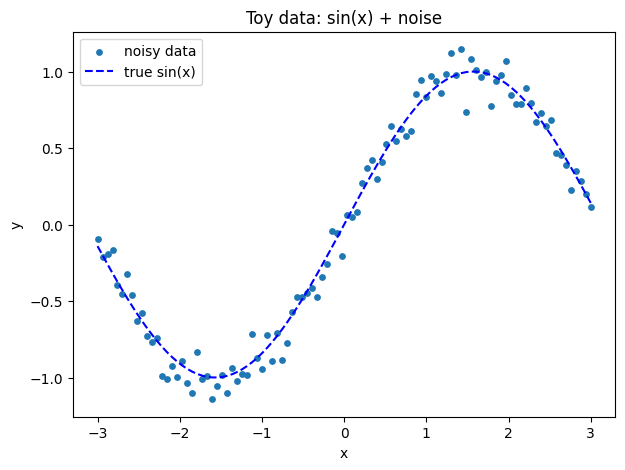

Final w:  0.33903284338492196 Final b: -0.010384651739409442
Final loss:  0.1954517971396205


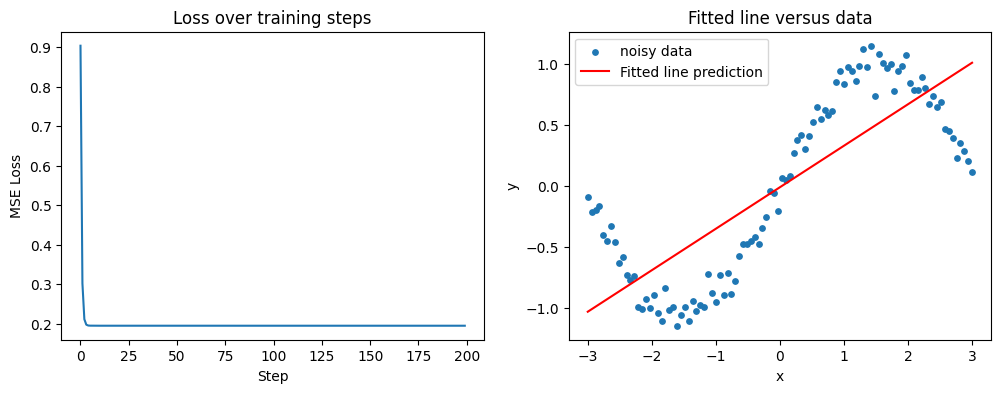

In [43]:
# TODO: Generate the toy data
np.random.seed(RANDOM_STATE)

x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0,0.1, size = x.shape)

#   Plot it.
plt.figure(figsize=(7,5))
plt.scatter(x, y, s = 15, label = "noisy data")
plt.plot(x, np.sin(x), color = "blue", linestyle = "--", label = "true sin(x)")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Toy data: sin(x) + noise")
plt.show()

# TODO: Initialise w and b to small random values.
w = np.random.randn()*0.1
b = np.random.randn()*0.1

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
#   y_hat = w * x + b
#   loss  = np.mean((y_hat - y) ** 2)               # MSE
#   dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
#   db    = np.mean(2 * (y_hat - y))                # dLoss/db
#   w    -= lr * dw
#   b    -= lr * db
#   Record the loss at every step.
lr = 0.1
n_steps = 200
losses = []

for step in range(n_steps):
  y_hat = w*x + b

  loss = np.mean((y_hat - y) ** 2)
  losses.append(loss)

  dw    = np.mean(2 * (y_hat - y) * x)
  db    = np.mean(2 * (y_hat - y))

  w    -= lr * dw
  b    -= lr * db

print("Final w: ", w, "Final b:", b)
print("Final loss: ", losses[-1])


# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.
fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].plot(losses)
axes[0].set_xlabel("Step")
axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Loss over training steps")

axes[1].scatter(x, y, s = 15, label = "noisy data")
axes[1].plot(x, w*x + b, color = "red", label = "Fitted line prediction")
axes[1].legend()
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_title("Fitted line versus data")

plt.show()

**Student Reasoning — The single neuron**
*1. Derive `dLoss/dw` on paper and include a photo or the LaTeX in this cell — does it match
the code?*
*2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting,
and WHY can a single neuron never fit a sine wave, no matter how long you train?*

> **Answer:
1.
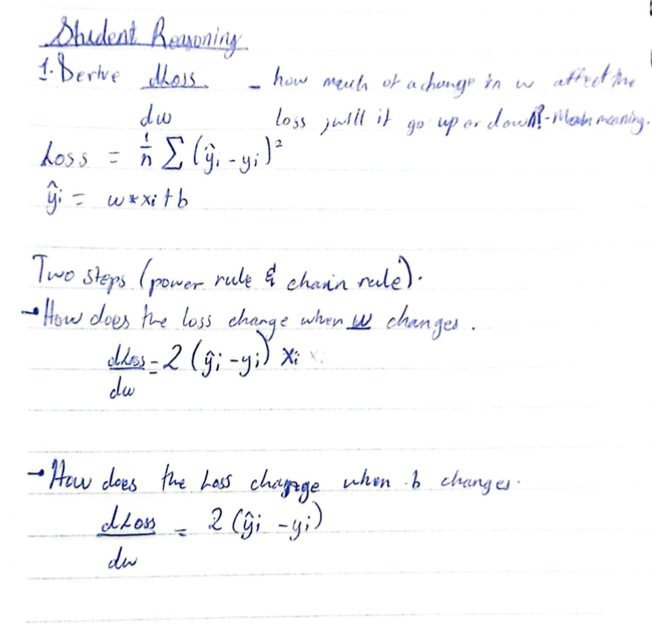

2. There is Underfitting the linear model is too simple for the sin(x) which presents data in a curvy form. From the graph the straght line(y_hat =w*x+b) is only ever what the linear model would generate and has a constant slope unlike the sin(x). So no matter how long the madel is trained the straight line will not bend to fit the sin(x) curvy data.

### Part 1.2 — Hidden layers and activations: why depth helps
Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.

Final loss:  0.8990595706569579


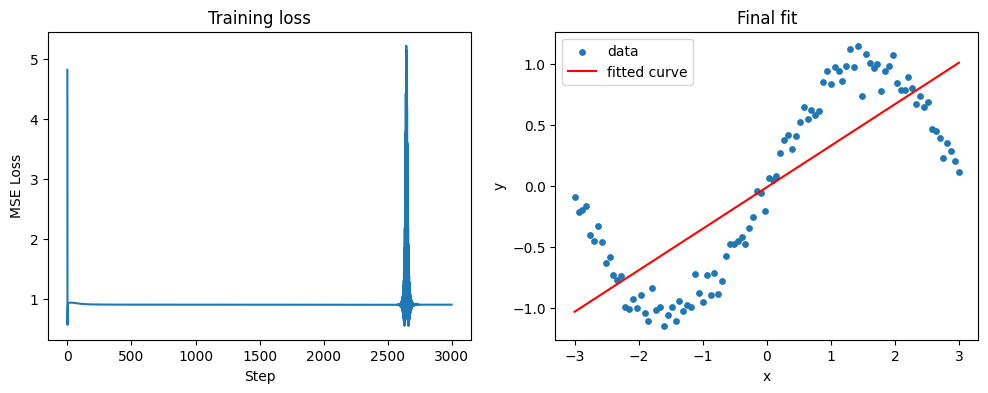

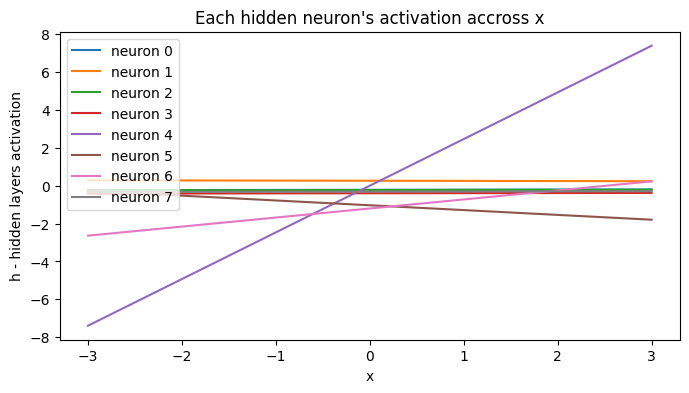

In [44]:
# TODO: Initialise parameters
#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
#   Small random values (e.g. np.random.randn(...) * 0.5)
np.random.seed(RANDOM_STATE)

W1 = np.random.randn(1,8) * 0.5
b1 = np.random.randn(8) * 0.5
W2 = np.random.randn(8,1) * 0.5
b2 = np.random.randn(1) * 0.5

x_col = x.reshape(-1,1)
y_col = y.reshape(-1,1)

# TODO: Forward pass (keep the intermediate values — you need them for backprop):
#   z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
#   h  = np.tanh(z1)        # activation
#   y_hat = h @ W2 + b2     # output, shape (100, 1)
#   loss  = np.mean((y_hat - y) ** 2)
z1 = x_col @ W1 + b1
h = z1
y_hat = h @ W2 + b2
loss = np.mean((y_hat - y_col) ** 2)


# TODO: Backward pass (the chain rule, layer by layer):
#   d_yhat = 2 * (y_hat - y) / len(y)
#   dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
#   dh  = d_yhat @ W2.T
#   dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
#   dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)
d_yhat = 2 * (y_hat - y_col) / len(y_col)

dW2 = h.T @ d_yhat
db2 = d_yhat.sum(axis=0)

dh  = d_yhat @ W2.T
dz1 = dh * (1 - np.tanh(z1) ** 2)

dW1 = x_col.T @ dz1
db1 = dz1.sum(axis=0)

# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.
lr = 0.05
n_steps = 3000
losses = []

np.random.seed(RANDOM_STATE)

W1 = np.random.randn(1,8) * 0.5
b1 = np.random.randn(8) * 0.5
W2 = np.random.randn(8,1) * 0.5
b2 = np.random.randn(1) * 0.5

for step in range(n_steps):
  z1 = x_col @ W1 + b1
  h = z1
  y_hat = h @ W2 + b2
  loss = np.mean((y_hat - y) ** 2)
  losses.append(loss)

  d_yhat = 2 * (y_hat - y_col) / len(y_col)
  dW2 = h.T @ d_yhat
  db2 = d_yhat.sum(axis=0)
  dh  = d_yhat @ W2.T
  dz1 = dh * (1 - np.tanh(z1) ** 2)
  dW1 = x_col.T @ dz1
  db1 = dz1.sum(axis=0)

  W1 -= lr * dW1
  b1 -= lr * db1
  W2 -= lr * dW2
  b2 -= lr * db2

print("Final loss: ", losses[-1])

# TODO: Plot the loss curve AND the final fit over the data.
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(losses)
axes[0].set_xlabel("Step")
axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Training loss")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

axes[1].scatter(x, y, s = 15, label =  "data")
axes[1].plot(x,y_hat, color = "red", label = "fitted curve")
axes[1].set_title("Final fit")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].legend()
plt.show()

plt.figure(figsize=(8,4))
for i in range(8):
  plt.plot(x, h[:, i],label =f"neuron {i}")
plt.xlabel("x")
plt.ylabel("h - hidden layers activation")
plt.title("Each hidden neuron's activation accross x")
plt.legend()
plt.show()


**Student Reasoning — Depth and activations**
*1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1.
Explain mathematically why a stack of linear layers collapses into one linear layer.*
*2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few columns of `h` against `x`.)*
*3. This is exactly what `loss.backward()` will automate in Section 2. In one sentence, what
is backpropagation?*

> **Answer:**
1. With the tahn removed, the gradient descent or network fit line comes out straight and no longer bends to fit the sin(x) function. Without the tanh the activation function h = z1 = xW1 + b1 and y_hat = hW2 +b2 which when combined turns into a linear function(y_hat= x(W1W2)+ W2b1+b2). This also proves that, without the non-linear model used through activation, if the model uses a linear function for the activation between stacks of layers for output, the results would be forced into one linear layer.

2. The 8 neurons in the hidden layers each have their own weights and biases and activation is done independently to present different curves because of the different weights and baises which are approximated and combined for the final output.

3. I think the backpropagation is a processes of working backwards to see how  the loss calculated based on the final output  using the chain rule at each layer ( from output to input layer) to also realise the contribution of each neuron to the final loss.

### Part 1.3 — The learning rate: too cold, too hot, just right
The single most important hyperparameter. See its three regimes with your own eyes.

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_682/4216034276.py:16: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y_col) ** 2)
/tmp/ipykernel_682/4216034276.py:22: RuntimeWarning: overflow encountered in matmul
  dh  = d_yhat @ W2.T
/tmp/ipykernel_682/4216034276.py:23: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


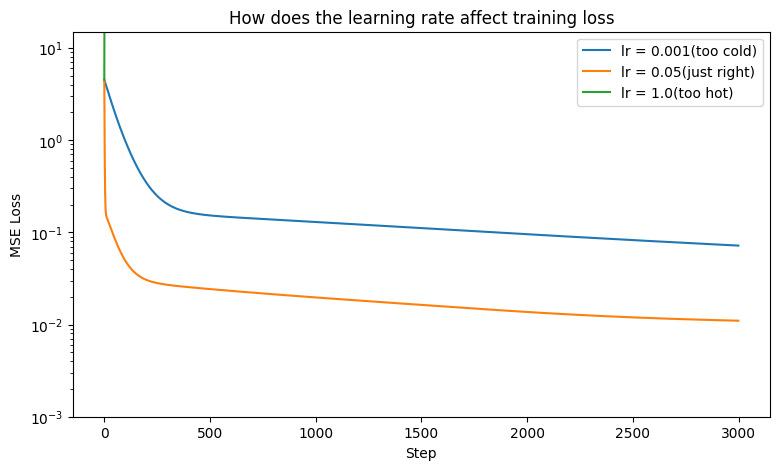

Final loss (lr=0.001): 0.07181850562493927
Final loss (lr=0.05): 0.010998766930595295
Final loss (lr=1.0): nan


In [45]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.
def train_toy(lr, steps = 3000):
  np.random.seed(RANDOM_STATE)

  W1 = np.random.randn(1,8) * 0.5
  b1 = np.random.randn(8) * 0.5
  W2 = np.random.randn(8,1) * 0.5
  b2 = np.random.randn(1) * 0.5

  losses = []
  for step in range(steps):
    z1 = x_col @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2
    loss = np.mean((y_hat - y_col) ** 2)
    losses.append(loss)

    d_yhat = 2 * (y_hat - y_col) / len(y_col)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh  = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    dW1 = x_col.T @ dz1
    db1 = dz1.sum(axis=0)

    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2
  return losses

# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).
losses_lr1 =train_toy(0.001)
losses_lr2 =train_toy(0.05)
losses_lr3 =train_toy(1.0)

# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.
plt.figure(figsize=(9,5))
plt.plot(losses_lr1, label = "lr = 0.001(too cold)")
plt.plot(losses_lr2, label = "lr = 0.05(just right)")
plt.plot(losses_lr3, label = "lr = 1.0(too hot)")
plt.xlabel("Step")
plt.ylabel("MSE Loss")
plt.yscale("log")
plt.title("How does the learning rate affect training loss")
plt.legend()
plt.ylim(1e-3, 15)
plt.show()

print("Final loss (lr=0.001):", losses_lr1[-1])
print("Final loss (lr=0.05):", losses_lr2[-1])
print("Final loss (lr=1.0):", losses_lr3[-1])

**Student Reasoning — Learning rate**
*Describe what each of the three curves shows. Why does a too-large learning rate make the
loss explode or oscillate instead of just "learning faster"?*

> **Answer:**
For the larger learning rate value (1.0) the line on the shows that it has past the last value on the y axis and is heading towards infininty and after printing the final loss it is NaN which means it is very hot and has exploded upwards. For the learning rate which is just right(0.05) has a final loss value of 0.011 from the graph it slowly/ smoothly approaches the low value. Lastly the low learning rate when it is too cold(0.001)  it has a loss value of 0.072 and when it is compared to the learning rate of 0.05 it is slower as it approaches its lowest value after the 3000 steps. I think what makes it oscilate is because when the learning rate is very high, during updates the gradient is multiplied by the learning rate. If it is too large it might overshoot past the loss and in a case where the gradient is also high the explosion will be way bigger. This simply means that the learning process may only get worse rather than better with a larger learning rate.

---
# Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (`autograd`, optimizers, batching) and apply the ideas
from Section 1 to a real problem — one you already know:

## Predicting obesity level (`NObeyesdad`) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural
network you design and train yourself. At the end you will compare it head-to-head with your
Lab 2 classical models.

### Part 2.1 — Preprocess and split (recycled from Lab 2)
Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.

In [46]:
# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
obesity = pd.read_csv(OBESITY_URL)



# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.

from sklearn.preprocessing import LabelEncoder

obesity['family_history_with_overweight'] = obesity['family_history_with_overweight'].map({'yes': 1, 'no': 0})
obesity['FAVC'] = obesity['FAVC'].map({'yes': 1, 'no': 0})
obesity['SMOKE'] = obesity['SMOKE'].map({'yes': 1, 'no': 0})
obesity['SCC']= obesity['SCC'].map({'yes': 1, 'no': 0})

ordinal_map =  {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
obesity['CAEC'] = obesity['CAEC'].map(ordinal_map)
obesity['CALC'] = obesity['CALC'].map(ordinal_map)

obesity = pd.get_dummies(obesity, columns = ['Gender', 'MTRANS'], drop_first = True, dtype = int)

t_encoder = LabelEncoder()
y = t_encoder.fit_transform(obesity['NObeyesdad'])

# categorical_features = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC','SMOKE', 'SCC', 'CALC', 'MTRANS']

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split




# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).
x_obe = obesity.drop('NObeyesdad', axis=1)
y_obe = y


x_temp, x_test, y_temp, y_test = train_test_split(x_obe, y_obe, test_size=0.2, random_state=RANDOM_STATE, stratify = y_obe)
x_train, x_val, y_train, y_val = train_test_split(x_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify = y_temp)

# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests —
#    remember Section 1, where all gradients depended on x!)

# TODO: Fit the scaler on the training set only, then transform train / val / test.

scaler_ob = StandardScaler()

numeric_cols_ob = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

x_train_scaled = x_train.copy()
x_val_scaled = x_val.copy()
x_test_scaled = x_test.copy()

x_train_scaled[numeric_cols_ob] = scaler_ob.fit_transform(x_train_scaled[numeric_cols_ob])
x_val_scaled[numeric_cols_ob] = scaler_ob.transform(x_val_scaled[numeric_cols_ob])
x_test_scaled[numeric_cols_ob] = scaler_ob.transform(x_test_scaled[numeric_cols_ob])

# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader

x_train_ten = torch.tensor(x_train_scaled.values, dtype = torch.float32)
y_train_ten = torch.tensor(y_train, dtype = torch.long)

x_val_ten = torch.tensor(x_val_scaled.values, dtype = torch.float32)
y_val_ten = torch.tensor(y_val, dtype = torch.long)

x_test_ten = torch.tensor(x_test_scaled.values, dtype = torch.float32)
y_test_ten = torch.tensor(y_test, dtype = torch.long)

train_dataset = TensorDataset(x_train_ten, y_train_ten)
val_dataset = TensorDataset(x_val_ten, y_val_ten)
test_dataset = TensorDataset(x_test_ten, y_test_ten)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


**Student Reasoning — Preprocessing for neural networks**
*1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in
PyTorch?*
*2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care
so much? Connect your answer to the gradient formulas you wrote in Section 1.*
*3. What does `shuffle=True` on the training DataLoader do, and why does it help?*

> **Answer:**
1. The CrossEntropyLoss needs to be in the integer label rather than a one hot vector because of the combinations done internally and it is also less costly as the classes grow. The integer is used to also directly index  the predicted probability of the correct class.

2.With neural networks caling is needed to help the machine learn better prevent machines from viewing it to be more valuable or greater than other features. The feature scalling helps tocompute for gradient and if input is too large the training might become unstable. But for random forest such computatuions are not done so the feature scaling is not directly affected.

3. Shuffle = TRUE is used  on training Dataloader to help rearrange the data to be used during each epoch. This ensures that the rows selected for each batch is representative of the datasets with random mix of classes for the model to generalize during training rather than memorising.

### Part 2.2 — Design the network
An MLP: input -> hidden layers with ReLU -> 7 output logits.

In [49]:
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)

# class FeedForwardNet(nn.Module):
#     def __init__(self, ...):
#         ...
#     def forward(self, x):
#         ...
class FeedForwardNet(nn.Module):
  def __init__(self, input_dim, hidden_sizes = (64,32),n_classes = 7):
    super().__init__()
    self.layer1 = nn.Linear(input_dim, hidden_sizes[0])
    self.relu1 = nn.ReLU()
    self.layer2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
    self.relu2 = nn.ReLU()
    self.output_Layer = nn.Linear(hidden_sizes[1], n_classes)

  def forward(self, x):
    x = self.layer1(x)
    x = self.relu1(x)
    x = self.layer2(x)
    x = self.relu2(x)
    x = self.output_Layer(x)
    return x

# TODO: Instantiate, move to DEVICE, print the model.
input_dim = x_train_scaled.shape[1]
model = FeedForwardNet(input_dim = input_dim ,hidden_sizes = (64, 32), n_classes=7)
model = model.to(DEVICE)
print(model)

# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total parameters:", total_params)

FeedForwardNet(
  (layer1): Linear(in_features=19, out_features=64, bias=True)
  (relu1): ReLU()
  (layer2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (output_Layer): Linear(in_features=32, out_features=7, bias=True)
)
Total parameters: 3591


**Student Reasoning — Architecture**
*1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.*
*2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.*
*3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)*

> **Answer:**
1. Counts for each layer is normally computed through the nn.Linear with the formula y_hat = xW^T + b.
hidden layer 1 = (19 * 64) + 64 = 1280
hidden layer 2 = (64 * 32) + 32 = 2080
output_Layer = (32 * 7) + 7 = 231.

2. The ReLU activation function is used rather than the tanh because it is able to remove or zero all negative  and maintain the positive values. This is also less costly when doing computations because there are lno exponentials as compared to tanh and helps to deal with vanishing gradient problem that may cause slower learning in deep networks.

3. Without the ReLU activation function nonlinearity would not be used to help fit in curves. If this is not used and linear activation is used between stacks of layers to provide the final outputs the predictions would be forced into linear results

### Part 2.3 — The training loop
The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.

Epoch  1/50 | train_loss=0.0293 train_acc=0.6793 | val_loss=0.0284 val_acc=0.7014
Epoch  2/50 | train_loss=0.0249 train_acc=0.7275 | val_loss=0.0244 val_acc=0.7441
Epoch  3/50 | train_loss=0.0214 train_acc=0.7709 | val_loss=0.0215 val_acc=0.7536
Epoch  4/50 | train_loss=0.0185 train_acc=0.8199 | val_loss=0.0187 val_acc=0.8199
Epoch  5/50 | train_loss=0.0161 train_acc=0.8586 | val_loss=0.0165 val_acc=0.8389
Epoch  6/50 | train_loss=0.0143 train_acc=0.8728 | val_loss=0.0148 val_acc=0.8578
Epoch  7/50 | train_loss=0.0126 train_acc=0.8926 | val_loss=0.0134 val_acc=0.8768
Epoch  8/50 | train_loss=0.0113 train_acc=0.8973 | val_loss=0.0122 val_acc=0.8791
Epoch  9/50 | train_loss=0.0101 train_acc=0.9210 | val_loss=0.0110 val_acc=0.9123
Epoch  10/50 | train_loss=0.0091 train_acc=0.9265 | val_loss=0.0100 val_acc=0.9123
Epoch  11/50 | train_loss=0.0084 train_acc=0.9336 | val_loss=0.0098 val_acc=0.9242
Epoch  12/50 | train_loss=0.0078 train_acc=0.9415 | val_loss=0.0087 val_acc=0.9313
Epoch  13/50 

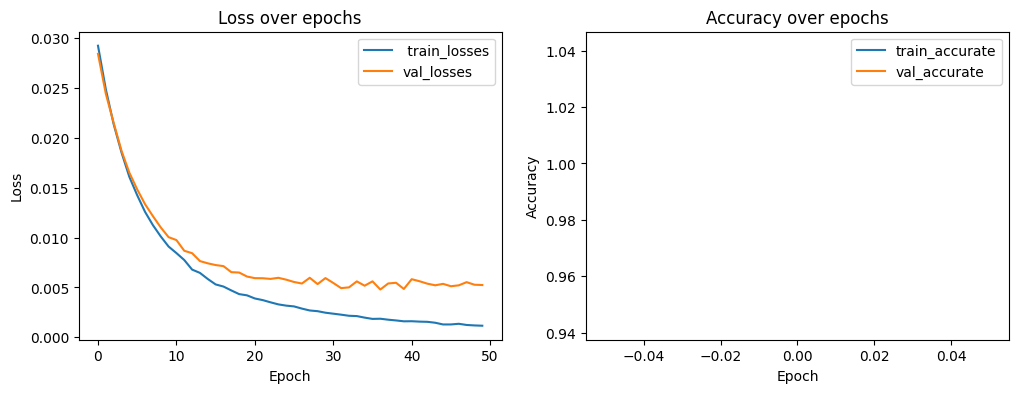

In [55]:
# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# TODO: Train for at least 50 epochs. Each epoch:
#   1. model.train(); for xb, yb in train_loader:
#        optimizer.zero_grad()
#        logits = model(xb.to(DEVICE))
#        loss = criterion(logits, yb.to(DEVICE))
#        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
#        optimizer.step()         # <- the update rule you wrote in Part 1.1
#   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
#   3. Append everything to history lists; print a one-line summary per epoch.
num_epochs = 50

train_losses = []
val_losses = []
train_accurates = []
val_accurates = []
best_val_accurate = 0.0

for epoch in range(num_epochs):
  model.train()
  running_loss = 0.0
  running_correct = 0
  total = 0
  for xb, yb in train_loader:

    optimizer.zero_grad()
    logits = model(xb.to(DEVICE))
    loss = criterion(logits, yb.to(DEVICE))
    loss.backward()
    optimizer.step()

    running_loss += loss.item()
    _, prediction = torch.max(logits.data, 1)
    total += yb.size(0)
    running_correct += (prediction == yb.to(DEVICE)).sum().item()

  train_loss = running_loss / total
  train_accurate = running_correct / total

  model.eval()
  val_running_loss = 0.0
  val_running_correct = 0
  val_total = 0

  with torch.no_grad():
    for xb, yb in val_loader:
      logits = model(xb.to(DEVICE))
      loss = criterion(logits, yb.to(DEVICE))
      val_running_loss += loss.item()

      _,prediction = torch.max(logits.data, 1)
      val_total += yb.size(0)
      val_running_correct += (prediction == yb.to(DEVICE)).sum().item()

  val_run_loss = val_running_loss / val_total
  val_run_accurate = val_running_correct / val_total

  train_losses.append(train_loss)
  val_losses.append(val_run_loss)
  train_accurates.append(train_accurate)
  val_accurates.append(val_run_accurate)

  if val_run_accurate > best_val_accurate:
        best_val_accurate = val_run_accurate
        torch.save(model.state_dict(), "ffn_best.pt")


  print(f"Epoch {epoch + 1: 2d}/{num_epochs} | "
        f"train_loss={train_loss:.4f} train_acc={train_accurate:.4f} | "
        f"val_loss={val_run_loss:.4f} val_acc={val_run_accurate:.4f}")
# TODO: Save the best model (highest validation accuracy):
#   torch.save(model.state_dict(), "ffn_best.pt")

# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.
fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].plot(train_losses, label=" train_losses")
axes[0].plot(val_losses, label="val_losses")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss over epochs")
axes[0].legend()

axes[1].plot(train_accurate, label="train_accurate")
axes[1].plot(val_accurate, label="val_accurate")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy over epochs")
axes[1].legend()

plt.show()


**Student Reasoning — Training**
*1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is
the forward pass, which computes gradients, which is the update rule?*
*2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the
specific numbers that back up your claim.*
*3. Why do we call `optimizer.zero_grad()` every batch? What silently goes wrong without it?*

> **Answer:**
1. The line for forward pass in PyTorch loop is "logits = model(xb.to(DEVICE))". The line for the computing of gradients is "loss.backwards()". Then lastly the line for applying updating rule is "optimizer.step()".

2. an amount of Overfitting: The model has memorised during training.

3. 'optimizer.zero_grad()' is called to be able to override old gradients when a new one is gotten to be used to clear old and new gradients would be added which will affect updates being made.

### Part 2.4 — Experiments: how training choices change the outcome
Run **three controlled experiments**. Change ONE thing at a time; keep everything else fixed.

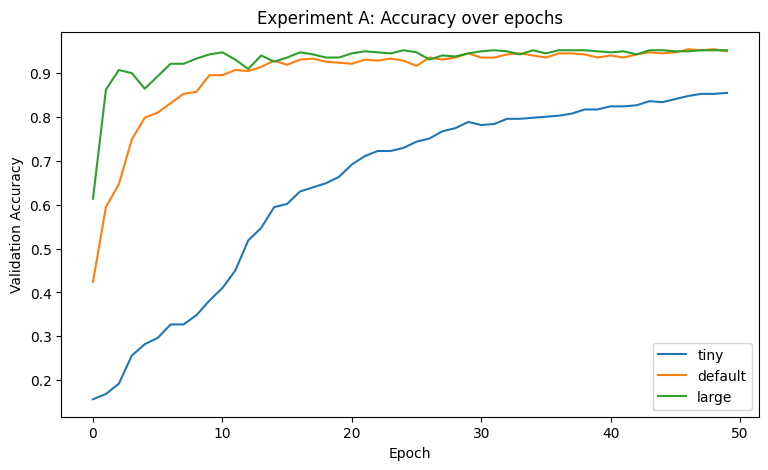

Final val_acc — tiny: 0.8554502369668247
Final val_acc — default: 0.9502369668246445
Final val_acc — large: 0.95260663507109
Final train_acc — large: 1.0


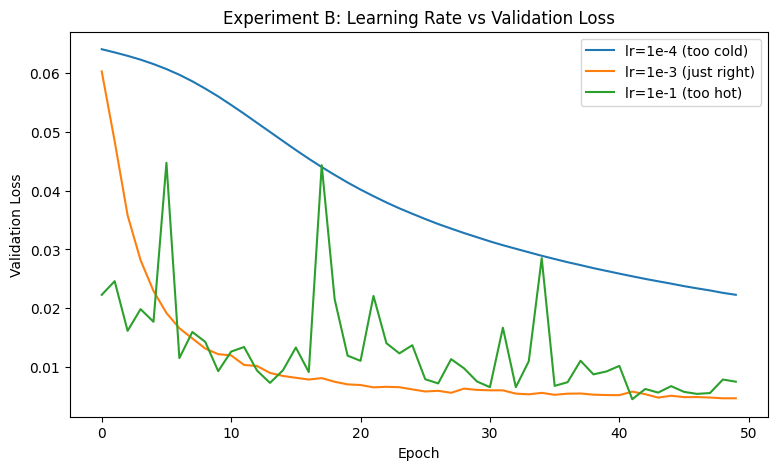

Final val_loss — lr=1e-4: 0.022294243082616003
Final val_loss — lr=1e-3: 0.0046934130473583234
Final val_loss — lr=1e-1: 0.007513594200119588


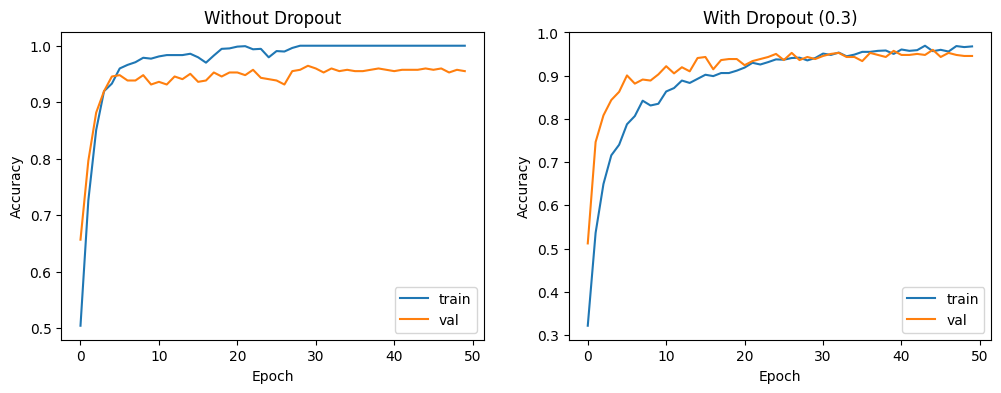

No dropout — final train_acc: 1.0 | final val_acc: 0.9549763033175356
Dropout 0.3 — final train_acc: 0.9676145339652449 | final val_acc: 0.9454976303317536


In [59]:
# Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...
class ExperimentNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes, n_classes=7, dropout=0.0):
        super().__init__()
        layers = []
        previous_size = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(previous_size, h))
            layers.append(nn.ReLU())
            if dropout > 0.0:
                layers.append(nn.Dropout(dropout))
            previous_size = h
        layers.append(nn.Linear(previous_size, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
    input_dim = x_train_scaled.shape[1]
    model = ExperimentNet(input_dim=input_dim, hidden_sizes=hidden_sizes, n_classes=7, dropout=dropout).to(DEVICE)

    train_loader_experiment = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader_experiment = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    L_history = {"train_losses": [], "val_losses": [], "train_accurates": [], "val_accurates": []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        running_correct = 0
        total = 0

        for xb, yb in train_loader_experiment:
            optimizer.zero_grad()
            logits = model(xb.to(DEVICE))
            loss = criterion(logits, yb.to(DEVICE))
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, prediction = torch.max(logits.data, 1)
            total += yb.size(0)
            running_correct += (prediction == yb.to(DEVICE)).sum().item()

        train_loss = running_loss / total
        train_accurate = running_correct / total

        model.eval()
        val_running_loss = 0.0
        val_running_correct = 0
        val_total = 0

        with torch.no_grad():
            for xb, yb in val_loader_experiment:
                logits = model(xb.to(DEVICE))
                loss = criterion(logits, yb.to(DEVICE))
                val_running_loss += loss.item()

                _, prediction = torch.max(logits.data, 1)
                val_total += yb.size(0)
                val_running_correct += (prediction == yb.to(DEVICE)).sum().item()

        val_run_loss = val_running_loss / val_total
        val_run_accurate = val_running_correct / val_total

        L_history["train_losses"].append(train_loss)
        L_history["val_losses"].append(val_run_loss)
        L_history["train_accurates"].append(train_accurate)
        L_history["val_accurates"].append(val_run_accurate)

    return L_history


# Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64)
history_tiny = run_experiment(hidden_sizes=(8,), epochs=50)
history_default = run_experiment(hidden_sizes=(64, 32), epochs=50)
history_large = run_experiment(hidden_sizes=(256, 128, 64), epochs=50)

plt.figure(figsize=(9,5))
plt.plot(history_tiny["val_accurates"], label="tiny")
plt.plot(history_default["val_accurates"], label="default")
plt.plot(history_large["val_accurates"], label="large")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Experiment A: Accuracy over epochs")
plt.legend()
plt.show()

print("Final val_acc — tiny:", history_tiny["val_accurates"][-1])
print("Final val_acc — default:", history_default["val_accurates"][-1])
print("Final val_acc — large:", history_large["val_accurates"][-1])
print("Final train_acc — large:", history_large["train_accurates"][-1])






# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.
# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
history_lr_low = run_experiment(hidden_sizes=(64, 32), lr=1e-4, epochs=50)
history_lr_mid = run_experiment(hidden_sizes=(64, 32), lr=1e-3, epochs=50)
history_lr_high = run_experiment(hidden_sizes=(64, 32), lr=1e-1, epochs=50)

plt.figure(figsize=(9,5))
plt.plot(history_lr_low["val_losses"], label="lr=1e-4 (too cold)")
plt.plot(history_lr_mid["val_losses"], label="lr=1e-3 (just right)")
plt.plot(history_lr_high["val_losses"], label="lr=1e-1 (too hot)")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Experiment B: Learning Rate vs Validation Loss")
plt.legend()
plt.show()

print("Final val_loss — lr=1e-4:", history_lr_low["val_losses"][-1])
print("Final val_loss — lr=1e-3:", history_lr_mid["val_losses"][-1])
print("Final val_loss — lr=1e-1:", history_lr_high["val_losses"][-1])

# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.
history_large_nodrop = run_experiment(hidden_sizes=(256, 128, 64), dropout=0.0, epochs=50)
history_large_drop = run_experiment(hidden_sizes=(256, 128, 64), dropout=0.3, epochs=50)

fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].plot(history_large_nodrop["train_accurates"], label="train")
axes[0].plot(history_large_nodrop["val_accurates"], label="val")
axes[0].set_title("Without Dropout")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history_large_drop["train_accurates"], label="train")
axes[1].plot(history_large_drop["val_accurates"], label="val")
axes[1].set_title("With Dropout (0.3)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.show()

print("No dropout — final train_acc:", history_large_nodrop["train_accurates"][-1],
      "| final val_acc:", history_large_nodrop["val_accurates"][-1])
print("Dropout 0.3 — final train_acc:", history_large_drop["train_accurates"][-1],
      "| final val_acc:", history_large_drop["val_accurates"][-1])

**Student Reasoning — Experiments**
*1. Capacity: did the largest network win on validation data? Where do you see diminishing
returns or overfitting?*
Yes it reached 0.953
*2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?*
*3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two
sentences HOW dropout achieves this.*

> **Answer:**
1.Yes it reached 0.953 and yes there is overfitting.
2.Yes it is matching.
3. Dropout is used to prevent memorization.

### Part 2.5 — Final evaluation and showdown with Lab 2
One honest number on the test set — then compare with your classical models.

Test Accuracy: 0.9456264775413712
Test Macro-F1: 0.9440033483143505

Classification Report:
                      precision    recall  f1-score   support

Insufficient_Weight       0.93      0.94      0.94        54
      Normal_Weight       0.91      0.84      0.88        58
     Obesity_Type_I       0.93      1.00      0.97        70
    Obesity_Type_II       0.98      0.95      0.97        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.87      0.95      0.91        58
Overweight_Level_II       1.00      0.93      0.96        58

           accuracy                           0.95       423
          macro avg       0.95      0.94      0.94       423
       weighted avg       0.95      0.95      0.95       423



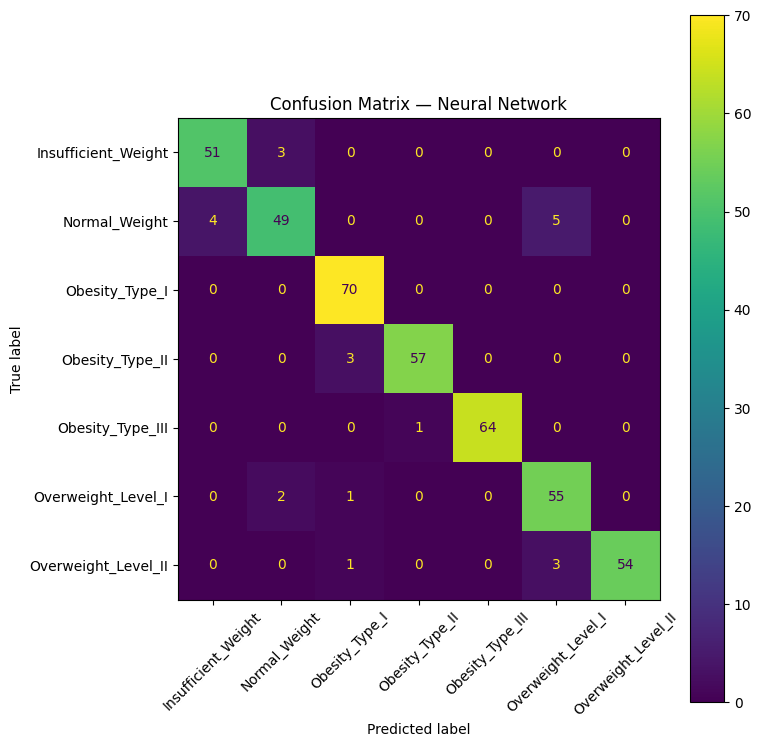

,Model,Test Accuracy,Test Macro-F1,Training Time (s),Params / Trees
0,Lab 2 Best Classifier (e.g. Random Forest),NaN,NaN,None,NaN
1,Neural Network (this lab),0.945626,0.944003,None,3591.0


In [61]:
# TODO: Load your best configuration's weights; model.eval().
input_dim = x_train_scaled.shape[1]
model = FeedForwardNet(input_dim=input_dim, hidden_sizes=(64, 32), n_classes=7)
model.load_state_dict(torch.load("ffn_best.pt"))
model = model.to(DEVICE)
model.eval()

all_preds = []
all_true = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        logits = model(xb)
        _, preds = torch.max(logits, 1)
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(yb.numpy())
# TODO: Report test ACCURACY and MACRO-F1
#   from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

test_acc = accuracy_score(all_true, all_preds)
test_f1 = f1_score(all_true, all_preds, average="macro")

print("Test Accuracy:", test_acc)
print("Test Macro-F1:", test_f1)
print("\nClassification Report:\n", classification_report(all_true, all_preds, target_names=t_encoder.classes_))

# TODO: Confusion matrix for the test set with the 7 class names
#   from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(8,8))
ConfusionMatrixDisplay.from_predictions(all_true, all_preds, display_labels=t_encoder.classes_,
                                          xticks_rotation=45, ax=ax)
plt.title("Confusion Matrix — Neural Network")
plt.tight_layout()
plt.show()
# TODO: Build a small comparison table (a pandas DataFrame is fine):
#   rows = [your best Lab 2 classifier, this neural network]
#   cols = [test accuracy, test macro-F1, training time, number of parameters/trees]
comparison = pd.DataFrame({
    "Model": ["Lab 2 Best Classifier (e.g. Random Forest)", "Neural Network (this lab)"],
    "Test Accuracy": [None, test_acc],          # <-- replace None with your Lab 2 test accuracy
    "Test Macro-F1": [None, test_f1],           # <-- replace None with your Lab 2 test macro-F1
    "Training Time (s)": [None, None],          # <-- fill in if you have both timings
    "Params / Trees": [None, sum(p.numel() for p in model.parameters() if p.requires_grad)]
})
comparison


**Student Reasoning — Final evaluation**
*1. Which obesity levels does the network still confuse, and are they the same ones your
Lab 2 classifier confused?*
*2. Who wins the showdown — the neural network or the classical model? Was the extra effort
of deep learning worth it on THIS dataset? When would it be?*

> **Answer:** [Double-click to edit]

---
# Section 3 — Reflection

*Answer in a few sentences each:*

1. **The black box, opened:** Name the three most important things happening inside
   `loss.backward()` and `optimizer.step()`, in your own words.
2. **Hyperparameters:** If you could tune only ONE hyperparameter on a new problem, which
   would you pick and why?
3. **Overfitting:** Across your experiments, where did you see the biggest
   train-vs-validation gap, and which intervention reduced it most?
4. **Looking ahead:** This network treats every input feature independently. Next lab we move
   to images, where nearby pixels are related. Why might a plain MLP struggle with images,
   and what property should a better architecture have?

> **Answer:**
1. - The old gradients are cleared.
- The new gradients are computed.
- Preventing the updates from being affected and production of large gradient values.

2.

---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel -> Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook (loss curves, fits, experiments, confusion matrix).
- [ ] Notebook committed and pushed to your `lab-3-feedforward-networks` repository, with
      incremental commits (not one final dump).
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository.